## Lab Practice Ensemble learning 1.4:  BOOSTING (CLASSWORK)  | Machine Learning II
#### ESU  Jan-2025
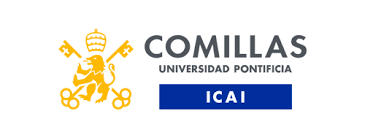

LEARNING OBJECTIVES
- How to run random forest with classification trees
- Deep understanding of the variability created by boostrap in the ensemble of trees

See

- Go to https://arogozhnikov.github.io/2016/06/24/gradient_boosting_explained.html     (regression)
- Next to https://arogozhnikov.github.io/2016/07/05/gradient_boosting_playground.html  (classification)

---
## Import modules

In [1]:
import numpy as np # linear algebra
import pandas as pd  # data management (dataframes)
import matplotlib.pyplot as plt
import seaborn as sns  # plotting

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from sklearn.inspection import permutation_importance

from sklearn.ensemble import GradientBoostingClassifier, AdaBoostRegressor, GradientBoostingRegressor
#from sklearn.ensemble import BaggingClassifier
#from sklearn.ensemble import BaggingRegressor
#from sklearn.ensemble import RandomForestClassifier

# solve problems with size and fonts in figures 
plt.rcParams['figure.dpi'] = 75

# auxiliary functions
import utils_ml1 as uml1
import utils_regression_ml2 as urml2
import utils_classification_ml2 as ucml2

---
## 1. Regression problem

#### 1.1 Set the synthetic problem

In [2]:
# Synthetic problem
np.random.RandomState(9999)

n = 1000
X = np.random.uniform(0, 10.0, size=n)
y_true = X * np.sin(X)
noise =  0.5 * (1 + X**0.8) * np.random.normal(scale=1, loc=0, size=n)
y = y_true + noise

#### 1.2 Split the dataset in TR and TS and plot the problem

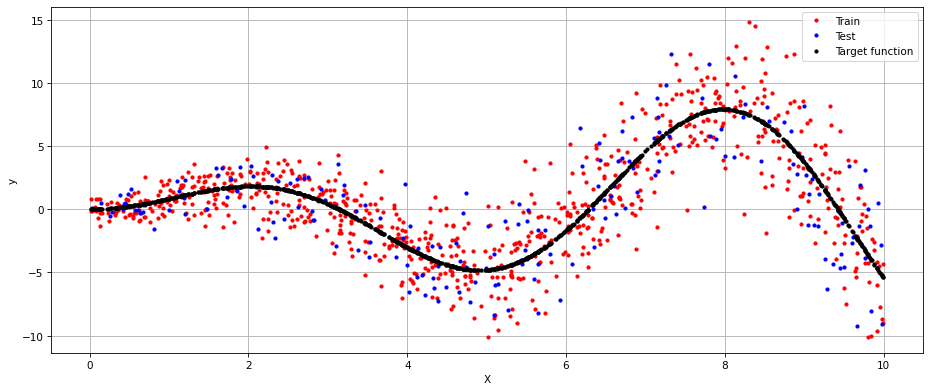

In [3]:
## 1.3 Split the dataset in TR and TS
 
# # Define input and output matrices
INPUTS = ['X']
OUTPUT = 'Y'

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,  #percentage of test data
                                                    random_state=0) #seed for replication
                                       
# Plot data
plt.figure(figsize=(15, 6))
plt.plot(X_train,y_train,'.r', label='Train')
plt.plot(X_test,y_test,'.b', label='Test')
plt.plot(X, y_true, '.', color = 'black', label='Target function')
plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.grid()
plt.show()

### 1.3 Fit **single regression tree** (for comparison)

A weak regression tree (profundidad máxima = 2)

In [4]:
## Inputs of the model
INPUTS_DT = INPUTS

# fit a regression tree with depth 2
weak_tree = DecisionTreeRegressor(max_depth=2)
weak_tree.fit(X_train.reshape(-1, 1), y_train)

print('Number of leaves:', weak_tree.get_n_leaves())
print('Params:')
weak_tree.get_params()

Number of leaves: 4
Params:


{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 2,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

Plot the weak tree

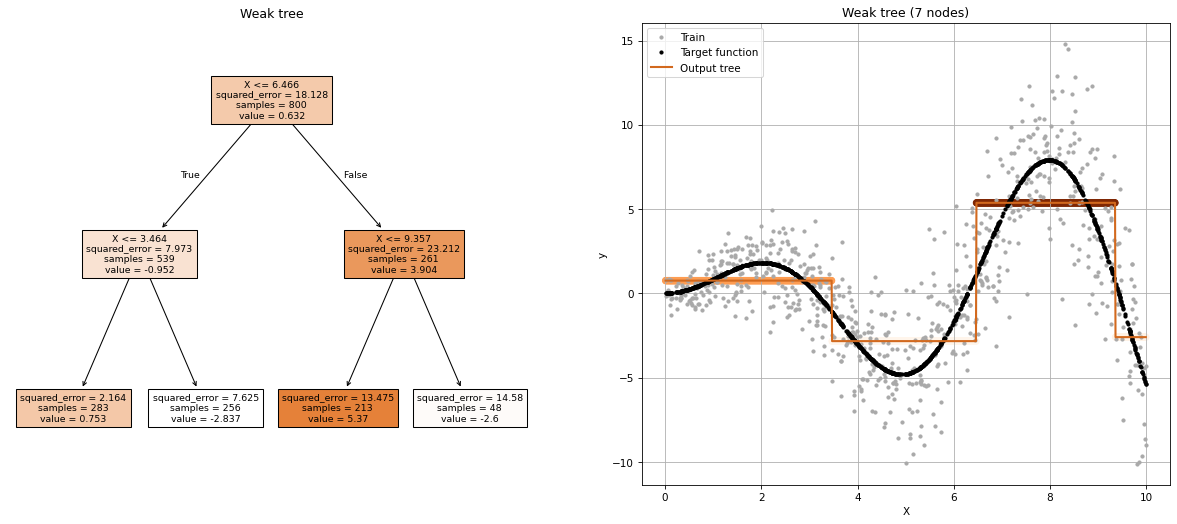

In [5]:

## Plot the decision tree model
plt.figure(figsize=(20, 8))
plt.subplot(1,2,1)
plot_tree(weak_tree,
          feature_names= INPUTS_DT,
          fontsize=9, filled=True)
plt.title('Weak tree')

# Predict
Xs = np.arange(np.min(X), np.max(X), 0.01).reshape(-1,1)
y_est = weak_tree.predict(Xs)

num_nodes = weak_tree.tree_.node_count

# Plot target output and the output of the tree
plt.subplot(1,2,2)
plt.plot(X_train,y_train,'.',color='darkgray', label='Train')
plt.plot(X, y_true, '.', color = 'black', label='Target function')
plt.plot(Xs, y_est, color = 'chocolate', linewidth= 2, label='Output tree')
plt.scatter(Xs, y_est, c= y_est, cmap='Oranges')
plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Weak tree ({num_nodes} nodes)')
plt.grid()
plt.show()

Fit the complexity for a single tree (grid search) 

In [6]:
# grid in min_impurity x min_samples_leaf x min_samples_split
param = {'DT__min_impurity_decrease': np.arange(0, 0.001 * np.var(y_train),0.001), # Minimum impurity to decrease in each split
         'DT__min_samples_leaf': np.arange(1,10,1), # Minimum number of obs in a terminal node
         'DT__min_samples_split':  np.arange(2,10,1)} # Minimum number of obs in node to keep cutting

# param = {'DT__min_impurity_decrease': np.arange(0,0.05,0.005)} # Minimum entropy to decrease in each split

pipe = Pipeline(steps=[('DT', DecisionTreeRegressor(criterion='squared_error',  # impurity measure: variance reduction
                                                     random_state=150))]) # For replication
                                                     
# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
single_reg_tree_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       cv=nFolds, # Number of Folds
                       refit=True) # (default) the best model is finally refitted using the whole training set **

single_reg_tree_fit.fit(X_train.reshape(-1, 1), y_train) # Search in grid

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('DT',
                                        DecisionTreeRegressor(random_state=150))]),
             n_jobs=-1,
             param_grid={'DT__min_impurity_decrease': array([0.   , 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008,
       0.009, 0.01 , 0.011, 0.012, 0.013, 0.014, 0.015, 0.016, 0.017,
       0.018]),
                         'DT__min_samples_leaf': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                         'DT__min_samples_split': array([2, 3, 4, 5, 6, 7, 8, 9])})

In [7]:
# Show the best grid parameter combination found by CV
single_reg_tree_fit.best_estimator_['DT'].get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': np.float64(0.016),
 'min_samples_leaf': np.int64(9),
 'min_samples_split': np.int64(2),
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 150,
 'splitter': 'best'}

In [ ]:
## Gráfico que muestra el mejor hiperparámetro.
MT.plotModelGridError(single_reg_tree_fit)

Plot the single regression tree

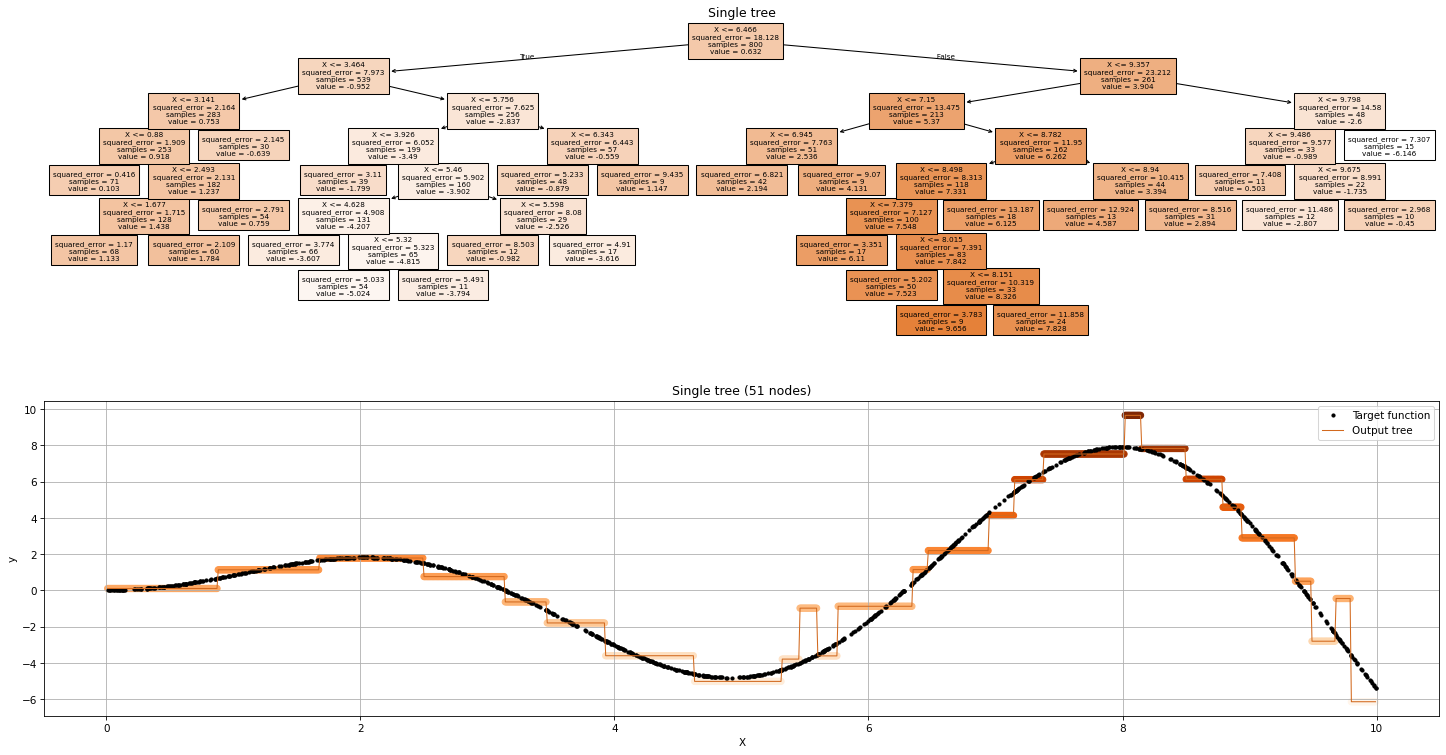

In [8]:
## Plot the decision tree model (use figsize and fontsize for getting the best view)
plt.figure(figsize=(24, 12))
plt.subplot(2,1,1)
plot_tree(single_reg_tree_fit.best_estimator_['DT'],
          feature_names= INPUTS_DT,
          fontsize=7, filled=True)
plt.title(f'Single tree')

plt.subplot(2,1,2)
# Predict
Xs = np.arange(np.min(X), np.max(X), 0.01).reshape(-1,1)
y_est_single_tree = single_reg_tree_fit.best_estimator_['DT'].predict(Xs)

num_nodes = single_reg_tree_fit.best_estimator_['DT'].tree_.node_count

# Plot
plt.plot(X, y_true, '.', color = 'black', label='Target function')
plt.plot(Xs, y_est_single_tree, color = 'chocolate', linewidth= 1, label='Output tree')
plt.scatter(Xs, y_est_single_tree, c = y_est_single_tree, cmap='Oranges')

plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Single tree ({num_nodes} nodes)')
plt.grid()
plt.show()

####### Hay que entender los colores del arbol: mas oscuros valores bajos mas oscuros valores bajos.

####### Más nodos: cuando la pendiente cambia más. El árbol da el valor de la horizonatal. En las zonas planas necesitamos menos nodos. El ruido va creciendo.

#####  Compute errors of the single regression tree and plot residuals

MSE(TR) = 4.633351874631435
MSE(TS) = 7.4988718436106145
MAE(TR) = 1.61608265683191
MAE(TS) = 2.080642053705083


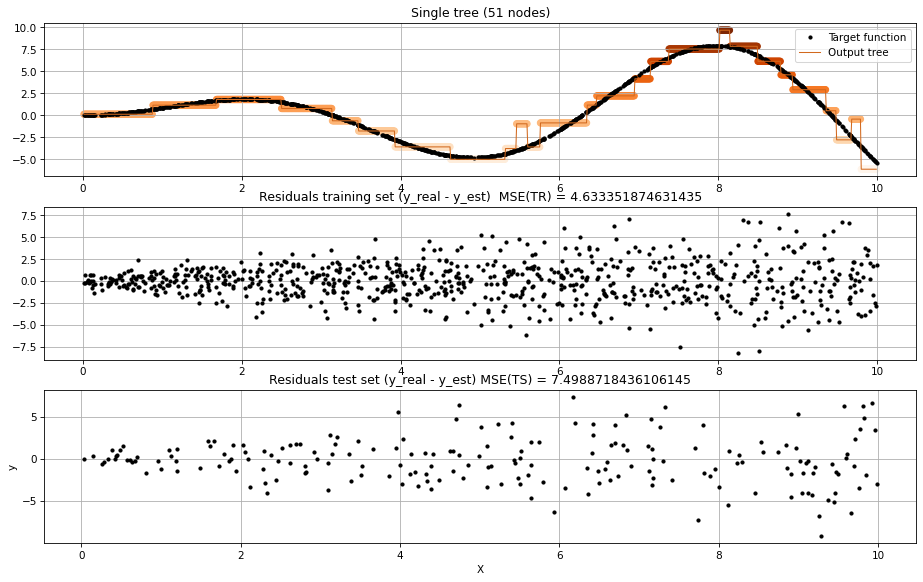

In [9]:
y_train_est = single_reg_tree_fit.best_estimator_['DT'].predict(X_train.reshape(-1, 1))
y_test_est = single_reg_tree_fit.best_estimator_['DT'].predict(X_test.reshape(-1, 1))

mse_tr = np.mean((y_train - y_train_est)**2)
mse_ts = np.mean((y_test - y_test_est)**2)

mae_tr = np.mean(np.abs(y_train - y_train_est))
mae_ts = np.mean(np.abs(y_test - y_test_est))


print(f'MSE(TR) = {mse_tr}')
print(f'MSE(TS) = {mse_ts}')

print(f'MAE(TR) = {mae_tr}')
print(f'MAE(TS) = {mae_ts}')

# Plot

plt.figure(figsize=(15, 9))

plt.subplot(3,1,1)
plt.plot(X, y_true, '.', color = 'black', label='Target function')
plt.plot(Xs, y_est_single_tree, color = 'chocolate', linewidth= 1, label='Output tree')
plt.scatter(Xs, y_est_single_tree, c = y_est_single_tree, cmap='Oranges')
plt.grid()
plt.legend()
plt.title(f'Single tree ({num_nodes} nodes)')


plt.subplot(3,1,2)
plt.plot(X_train, y_train - y_train_est, '.', color = 'black')
plt.grid()
plt.title(f'Residuals training set (y_real - y_est)  MSE(TR) = {mse_tr}')

plt.subplot(3,1,3)
plt.plot(X_test, y_test - y_test_est, '.', color = 'black')
plt.title(f'Residuals test set (y_real - y_est) MSE(TS) = {mse_ts}')
plt.grid()
plt.xlabel('X')
plt.ylabel('y')
plt.show()


### Hay más error para x grande  (la varianza de lo residuos con x aumenta). El ruido depende de x. 
### Además, el error es mayor en la zona de la función que tiene más pendiente.
### Podríamos decir que hay overfitting.

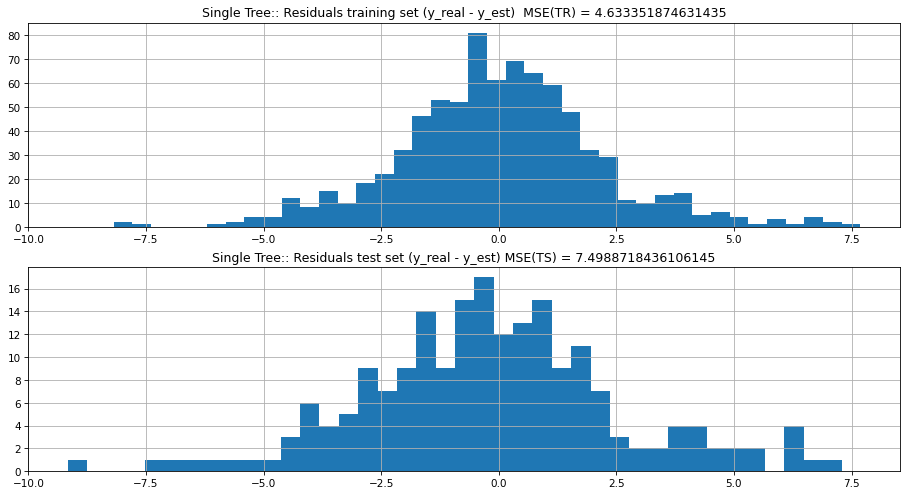

In [10]:
## Distribución de los residuos para train y para test.

urml2.plot_histogram_residuals_tr_ts('Single Tree', y_train, y_train_est, y_test, y_test_est, mse_tr, mse_ts)

#### No es una normal, las colas son muy grandes. El ruido no era uniforme.

### 1.4 Fit AdaBoost 

In [11]:
## Número de árboles que vamos a usar, de tal manera que el siguiente corrige los errores del anterior.
n_estimators=5000
### Hemos decidido hacerlo con arboles de profundidad 4.
max_depth = 4
min_impurity_decrease =  0.001 * np.var(y_train)
AdaBoost_reg_tree_fit = AdaBoostRegressor(                                 # Tenemos que asignar el modelo que queremos usar.
                                DecisionTreeRegressor(max_depth=max_depth,
                                                      min_impurity_decrease=min_impurity_decrease), 
                                n_estimators=n_estimators,

                                random_state=999)

AdaBoost_reg_tree_fit.fit(X.reshape(-1, 1), y)
AdaBoost_reg_tree_fit.get_params()

{'estimator__ccp_alpha': 0.0,
 'estimator__criterion': 'squared_error',
 'estimator__max_depth': 4,
 'estimator__max_features': None,
 'estimator__max_leaf_nodes': None,
 'estimator__min_impurity_decrease': np.float64(0.01812802116430394),
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__monotonic_cst': None,
 'estimator__random_state': None,
 'estimator__splitter': 'best',
 'estimator': DecisionTreeRegressor(max_depth=4,
                       min_impurity_decrease=np.float64(0.01812802116430394)),
 'learning_rate': 1.0,
 'loss': 'linear',
 'n_estimators': 5000,
 'random_state': 999}

Plot estimation

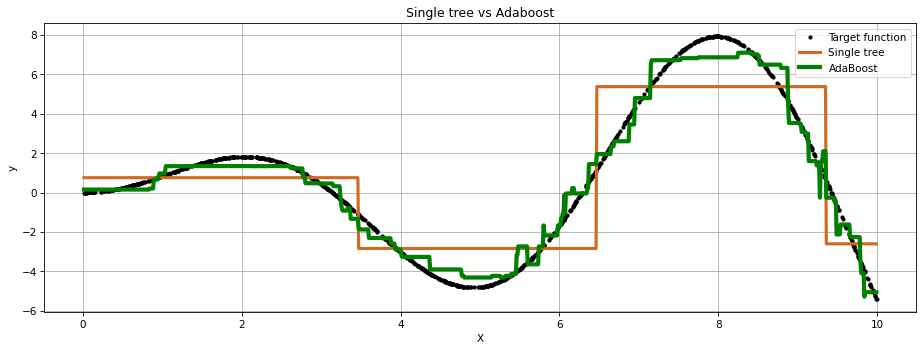

In [12]:
## Plot
plt.figure(figsize=(15, 5))

# Predict
Xs = np.arange(np.min(X), np.max(X), 0.01).reshape(-1,1)
y_est_adaboost = AdaBoost_reg_tree_fit.predict(Xs)

# Plot
plt.plot(X, y_true, '.', color = 'black', label='Target function')
plt.plot(Xs, y_est, color = 'chocolate', linewidth= 3, label='Single tree')
plt.plot(Xs, y_est_adaboost, color = 'green', linewidth= 4, label='AdaBoost')

plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Single tree vs Adaboost')
plt.grid()
plt.show()

Compute residuals AdaBoost and plot residuals

MSE(TR) = 5.034805731262955
MSE(TS) = 6.068208812398592
MAE(TR) = 1.7017660243578507
MAE(TS) = 1.9045948471702412


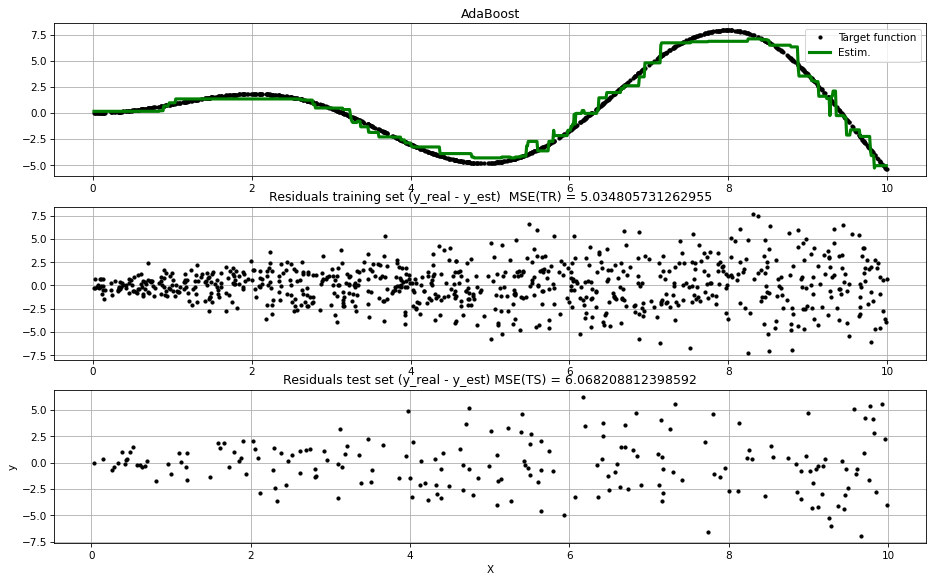

In [13]:
##  Compute errors
y_train_est =  AdaBoost_reg_tree_fit.predict(X_train.reshape(-1, 1))
y_test_est =  AdaBoost_reg_tree_fit.predict(X_test.reshape(-1, 1))

mse_tr = np.mean((y_train - y_train_est)**2)
mse_ts = np.mean((y_test - y_test_est)**2)

mae_tr = np.mean(np.abs(y_train - y_train_est))
mae_ts = np.mean(np.abs(y_test - y_test_est))

print(f'MSE(TR) = {mse_tr}')
print(f'MSE(TS) = {mse_ts}')

print(f'MAE(TR) = {mae_tr}')
print(f'MAE(TS) = {mae_ts}')

# Plot
plt.figure(figsize=(15, 9))

plt.subplot(3,1,1)
plt.plot(X, y_true, '.', color = 'black', label='Target function')
plt.plot(Xs, y_est_adaboost, color = 'green', linewidth= 3, label='Estim.')
plt.grid()
plt.legend()
plt.title(f'AdaBoost')


plt.subplot(3,1,2)
plt.plot(X_train, y_train - y_train_est, '.', color = 'black')
plt.grid()
plt.title(f'Residuals training set (y_real - y_est)  MSE(TR) = {mse_tr}')

plt.subplot(3,1,3)
plt.plot(X_test, y_test - y_test_est, '.', color = 'black')
plt.title(f'Residuals test set (y_real - y_est) MSE(TS) = {mse_ts}')
plt.grid()
plt.xlabel('X')
plt.ylabel('y')
plt.show()

#### Ya no tenemos overfitting, como nos pasaba con el arbol simple.

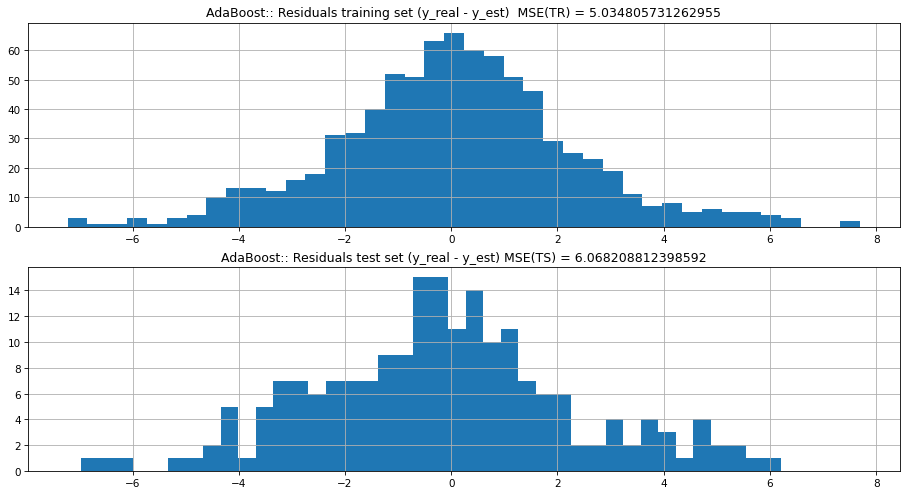

In [14]:
urml2.plot_histogram_residuals_tr_ts('AdaBoost', y_train, y_train_est, y_test, y_test_est, mse_tr, mse_ts)

### 1.5 Gradient boosting 

In [15]:
## Gradient Boosting para regresión. (sin grid search)

#Arboles tocones
## En gradient boosting tenemos que fijar además un valor para el learning rate.
number_estimators = 5000
learning_rate = 1.0
max_depth = 1
min_impurity_decrease =  0.001 * np.var(y_train)

GB_reg_estim = GradientBoostingRegressor(n_estimators=number_estimators,
                                            learning_rate = learning_rate,
                                            max_depth = max_depth,
                                            max_features = 1.0, # 'auto', ‘sqrt’, ‘log2’, int or float, default=None. En cada árbol, selecciona aleatoriamente max_features variables y solo esas pueden ser usadas en todo el árbol para las divisiones.
                                            loss = 'squared_error',  
                                            min_impurity_decrease = min_impurity_decrease,  
                                            min_samples_split=2, # Minimum number of obs in node to keep cutting
                                            min_samples_leaf=1, # Minimum number of obs in a terminal node  
                                            random_state=0)

GB_reg_estim.fit(X.reshape(-1, 1), y)

# see all the params
GB_reg_estim.get_params() 

{'alpha': 0.9,
 'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 1.0,
 'loss': 'squared_error',
 'max_depth': 1,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'min_impurity_decrease': np.float64(0.01812802116430394),
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 5000,
 'n_iter_no_change': None,
 'random_state': 0,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

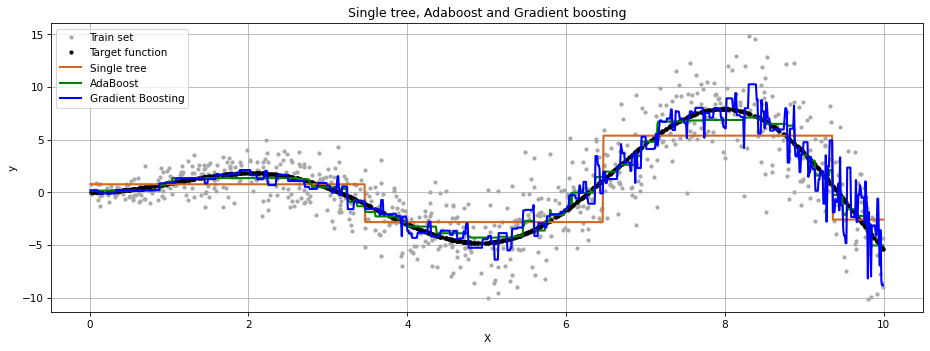

In [16]:
## Plot
plt.figure(figsize=(15, 5))

# Predict
Xs = np.arange(np.min(X), np.max(X), 0.01).reshape(-1,1)
y_est_GB = GB_reg_estim.predict(Xs)

# Plot
plt.plot(X_train,y_train,'.',color='darkgray', label='Train set')
plt.plot(X, y_true, '.', color = 'black', label='Target function')
plt.plot(Xs, y_est, color = 'chocolate', linewidth= 2, label='Single tree')
plt.plot(Xs, y_est_adaboost, color = 'green', linewidth= 2, label='AdaBoost')
plt.plot(Xs, y_est_GB, color = 'blue', linewidth= 2, label='Gradient Boosting')

plt.legend()
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Single tree, Adaboost and Gradient boosting')
plt.grid()
plt.show()

MSE(TR) = 3.0730252213124123
MSE(TS) = 3.4828447667907163
MAE(TR) = 1.317971991554587
MAE(TS) = 1.4371093891703737


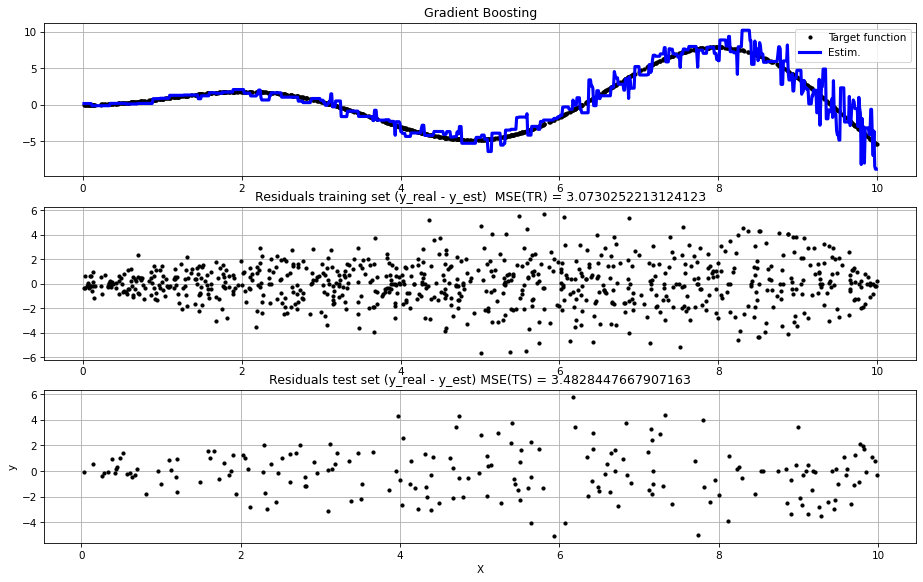

In [17]:
##  Compute errors
y_train_est =  GB_reg_estim.predict(X_train.reshape(-1, 1))
y_test_est =  GB_reg_estim.predict(X_test.reshape(-1, 1))

mse_tr = np.mean((y_train - y_train_est)**2)
mse_ts = np.mean((y_test - y_test_est)**2)

mae_tr = np.mean(np.abs(y_train - y_train_est))
mae_ts = np.mean(np.abs(y_test - y_test_est))

print(f'MSE(TR) = {mse_tr}')
print(f'MSE(TS) = {mse_ts}')

print(f'MAE(TR) = {mae_tr}')
print(f'MAE(TS) = {mae_ts}')

# Plot
plt.figure(figsize=(15, 9))

plt.subplot(3,1,1)
plt.plot(X, y_true, '.', color = 'black', label='Target function')
plt.plot(Xs, y_est_GB, color = 'blue', linewidth= 3, label='Estim.')
plt.grid()
plt.legend()
plt.title(f'Gradient Boosting')

plt.subplot(3,1,2)
plt.plot(X_train, y_train - y_train_est, '.', color = 'black')
plt.grid()
plt.title(f'Residuals training set (y_real - y_est)  MSE(TR) = {mse_tr}')

plt.subplot(3,1,3)
plt.plot(X_test, y_test - y_test_est, '.', color = 'black')
plt.title(f'Residuals test set (y_real - y_est) MSE(TS) = {mse_ts}')
plt.grid()
plt.xlabel('X')
plt.ylabel('y')
plt.show()

#### Parece que ha mejorado. Lo que no nos gusta es el ruido que tiene.
### Tiene más ruido porque hay más árboles, al ser donde más van fallando. Además, la pendiente es mayor y por lo tanto lo es el gradiente.

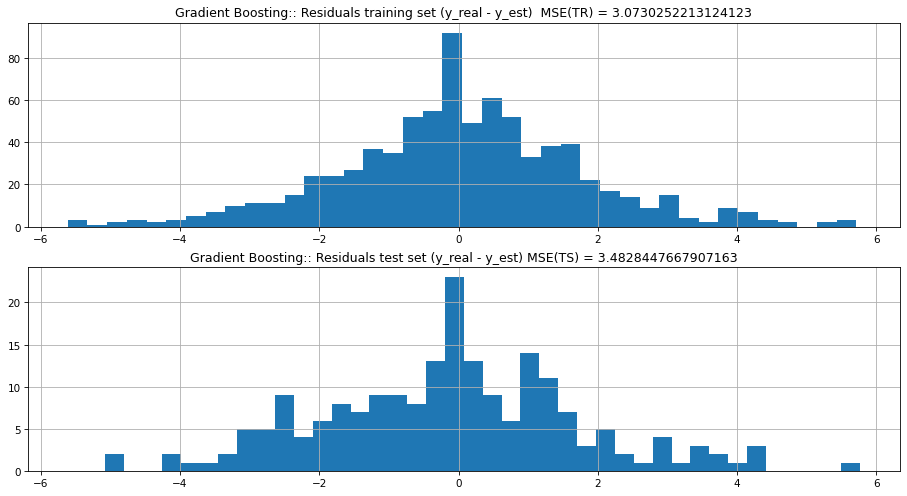

In [18]:
urml2.plot_histogram_residuals_tr_ts('Gradient Boosting', y_train, y_train_est, y_test, y_test_est, mse_tr, mse_ts)

---
## 1. Classification problem

#### 2.1 Load the dataset

In [19]:
# Load file with the dataset
df = pd.read_csv('simDataTriangle.dat', sep = "\t")
print('Dataframe:')
print(df.head())

# Convert output variable to categorical
df.Y = df.Y.astype('category')

Dataframe:
         X1        X2        X3        X4        X5        X6    Y
0 -0.416315  5.704369 -0.520502  5.624744 -0.567509  5.657103  OUT
1 -0.052473  9.467372 -0.308278  9.518659 -0.028233  9.271118  OUT
2 -0.552123  7.329100 -0.563368  7.373105 -0.851291  7.175183  OUT
3  0.290578  7.804284  0.248642  7.461996 -0.038654  7.557059  INS
4  0.116236  7.472282  0.154657  7.231131  0.154816  7.462239  INS


#### 2.2 Exploratory analysis

In [20]:
# Basic exploratory analysis

print('\nInfo variables:')
print(df.describe())


Info variables:
               X1          X2          X3          X4          X5          X6
count  700.000000  700.000000  700.000000  700.000000  700.000000  700.000000
mean     0.484328    6.115594    0.488827    6.124073    0.487352    6.121143
std      0.606122    2.678621    0.633653    2.686707    0.632867    2.687277
min     -0.597901    0.010610   -0.906872   -0.182318   -0.973871   -0.090703
25%     -0.045126    4.507014   -0.009401    4.432009   -0.004716    4.415462
50%      0.475767    6.614707    0.508919    6.619594    0.479645    6.572260
75%      1.023133    8.265262    0.998416    8.306398    0.990994    8.278550
max      1.499564    9.976869    1.982567   10.558648    1.924748   10.294785


#### 2.3 Split the dataset in TR and TS

In [21]:
# Define input and output matrices
INPUTS = ['X1','X2','X3','X4','X5','X6']
OUTPUT = 'Y'
X = df[INPUTS]
y = df[OUTPUT]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,  #percentage of test data
                                                    random_state=0, #seed for replication
                                                    stratify = y)   #Preserves distribution of y

### 2.4 Fit **single classification tree** (for comparison)

In [22]:
## Inputs of the model
INPUTS_DT = INPUTS

# grid in min_impurity x min_samples_leaf x min_samples_split
param = {'DT__min_impurity_decrease': np.arange(0,0.05,0.005), # Minimum entropy to decrease in each split
         'DT__min_samples_leaf': np.arange(1,10,1), # Minimum number of obs in a terminal node
         'DT__min_samples_split':  np.arange(1,10,1)} # Minimum number of obs in node to keep cutting

# param = {'DT__min_impurity_decrease': np.arange(0,0.05,0.005)} # Minimum entropy to decrease in each split

pipe = Pipeline(steps=[('DT', DecisionTreeClassifier(criterion='gini',  # impurity measure
                                                     random_state=150))]) # For replication
                                                     
# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
tree_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds, # Number of Folds 
                       refit=True) # (default) the best model is finally refitted using the whole training set **

tree_fit.fit(X_train[INPUTS_DT], y_train) # Search in grid

/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
900 fits failed out of a total of 8100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
900 fits failed with the following error:
Traceback (most recent call last):
  File "/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Applications/anaconda3/envs/ML2-2025/lib/python3.11/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Applications/anaconda3/envs/ML2-20

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('DT',
                                        DecisionTreeClassifier(random_state=150))]),
             n_jobs=-1,
             param_grid={'DT__min_impurity_decrease': array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045]),
                         'DT__min_samples_leaf': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                         'DT__min_samples_split': array([1, 2, 3, 4, 5, 6, 7, 8, 9])},
             scoring='accuracy')

In [23]:
# Show the best grid parameter combination found by CV
tree_fit.best_estimator_['DT'].get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': np.float64(0.0),
 'min_samples_leaf': np.int64(3),
 'min_samples_split': np.int64(8),
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 150,
 'splitter': 'best'}

##### 2.4.1 Plot the single classification tree

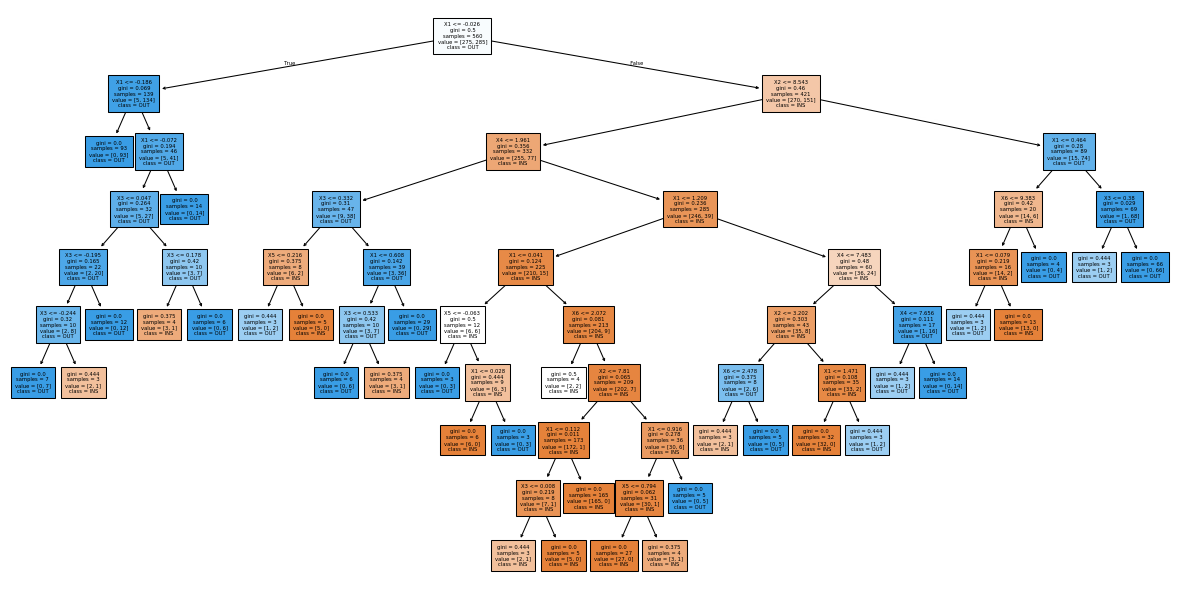

In [24]:
## Plot the decision tree model (use figsize and fontsize for getting the best view)
plt.figure(figsize=(20, 10))
plot_tree(tree_fit.best_estimator_['DT'],
          feature_names= INPUTS_DT,
          class_names= [str(s) for s in y_train.unique()],
          fontsize=5, filled=True)
plt.show()

##### 2.4.2 Compute errors of the single classification tree

In [25]:
# model predictions in training (TR) and test (TS) sets
clf = tree_fit.best_estimator_['DT']
y_train_pred = clf.predict(X_train[INPUTS_DT]).tolist()
y_test_pred = clf.predict(X_test[INPUTS_DT]).tolist()

# main metrics
acc_tr = metrics.accuracy_score(y_train,y_train_pred)
acc_ts = metrics.accuracy_score(y_test,y_test_pred)

acc_bal_tr = metrics.balanced_accuracy_score(y_train,y_train_pred)
acc_bal_ts = metrics.balanced_accuracy_score(y_test,y_test_pred)

dfacc =  pd.DataFrame([[acc_tr, acc_ts], [acc_bal_tr, acc_bal_ts]], index= ['Accuracy', 'Balanced accuracy'],  columns=['TR', 'TS'])
print(dfacc)

print('\nMETRICS TRAINING:')
uml1.confusion_matrix(y_train, y_train_pred, labels=['INS','OUT'])
print('\nMETRICS TEST SET:')
uml1.confusion_matrix(y_test, y_test_pred, labels=['INS','OUT'])

                         TR        TS
Accuracy           0.976786  0.885714
Balanced accuracy  0.976874  0.885691

METRICS TRAINING:
Confusion Matrix and Statistics
	   Prediction
Reference  INS  OUT
      INS  270    5
      OUT    8  277

Accuracy: 0.98
No Information Rate: 0.5
Kappa: 0.95
Mcnemar's Test P-Value: 0.58
Sensitivity: 0.97
Specificity: 0.98
Precision: 0.97
Recall: 0.98
Prevalence: 0.51
Detection Rate: 0.49
Detection prevalence: 0.5
Balanced accuracy: 0.98
F1 Score: 0.98
Positive label: INS

METRICS TEST SET:
Confusion Matrix and Statistics
	   Prediction
Reference  INS  OUT
      INS   61    8
      OUT    8   63

Accuracy: 0.89
No Information Rate: 0.5
Kappa: 0.77
Mcnemar's Test P-Value: 1.0
Sensitivity: 0.89
Specificity: 0.88
Precision: 0.88
Recall: 0.88
Prevalence: 0.51
Detection Rate: 0.45
Detection prevalence: 0.51
Balanced accuracy: 0.89
F1 Score: 0.88
Positive label: INS


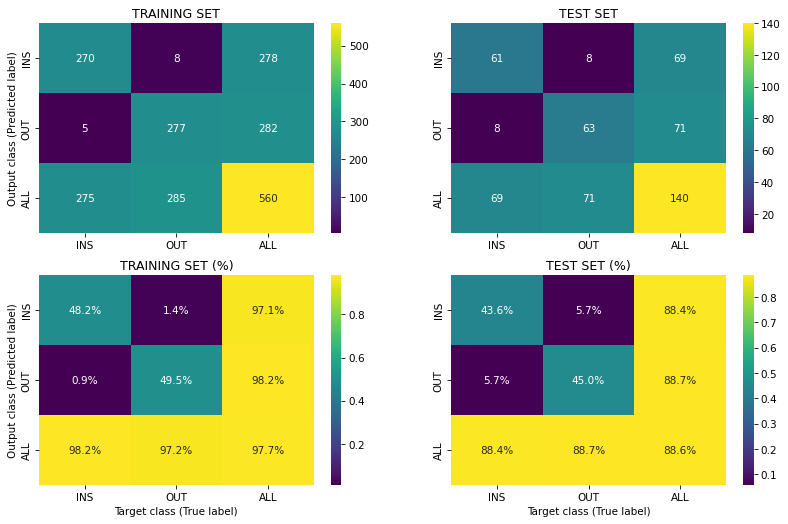

In [26]:
ucml2.plot_expanded_confusion_matrix(clf, X_train, y_train, X_test, y_test)

### 2.5 Gradient Boosting

See **HistGradientBoostingClassifier**, inspired by **LightGBM**.

HistGradientBoostingClassifier is much faster than GradientBoostingClassifier for big datasets (n_samples >= 10 000).

**This estimator first bins the input samples X into integer-valued bins (typically 256 bins) which tremendously reduces the number of splitting points to consider, and allows the algorithm to leverage integer-based data structures (histograms) instead of relying on sorted continuous values when building the trees.**

El HistGradientBoostingClassifier es una implementación optimizada del algoritmo de Gradient Boosting, inspirada en la librería LightGBM. Este modelo es mucho más rápido que el GradientBoostingClassifier estándar cuando trabajamos con conjuntos de datos grandes, es decir, con más de 10,000 muestras.

¿Por qué es más rápido?

Este modelo introduce una optimización clave: antes de entrenar el modelo, agrupa los valores de las variables en un número limitado de “cajas” o bins (por defecto, 256 bins).

##### 2.5.1 First straightforward version (without optim hyperparameters)

In [35]:
# The features are always randomly permuted at each split.

## loss{'log_loss', 'deviance', 'exponential'}, default='log_loss'
#  'log_loss' refers to binomial and multinomial deviance (as in logistic regression). It is a good choice for classification with probabilistic outputs. 
#  'exponential', gradient boosting recovers the AdaBoost algorithm.

## learning_rate float, default=0.1
#  Learning rate shrinks the contribution of each tree 
#  There is a trade-off between learning_rate and n_estimators.

In [27]:
number_estimators = 1000
learning_rate = 1.0
max_depth = 1

GB_class_estim = GradientBoostingClassifier(n_estimators=number_estimators,
                                            learning_rate = learning_rate,
                                            max_depth = max_depth,
                                            max_features = 1.0, # 'auto', ‘sqrt’, ‘log2’, int or float, default=None
                                            loss = 'log_loss',   # binomial and multinomial deviance
                                            min_samples_split=2, # Minimum number of obs in node to keep cutting
                                            min_samples_leaf=1, # Minimum number of obs in a terminal node  
                                            random_state=0)

# see all the params
GB_class_estim.get_params() 

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 1.0,
 'loss': 'log_loss',
 'max_depth': 1,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 1000,
 'n_iter_no_change': None,
 'random_state': 0,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [28]:
# fit
INPUTS_BT = INPUTS                
GB_class_estim.fit(X_train[INPUTS_BT], y_train)

GradientBoostingClassifier(learning_rate=1.0, max_depth=1, max_features=1.0,
                           n_estimators=1000, random_state=0)

In [29]:
# model predictions in training (TR) and test (TS) sets
clf = GB_class_estim
y_train_pred = clf.predict(X_train[INPUTS_DT]).tolist()
y_test_pred = clf.predict(X_test[INPUTS_DT]).tolist()

# main metrics
acc_tr = metrics.accuracy_score(y_train,y_train_pred)
acc_ts = metrics.accuracy_score(y_test,y_test_pred)

acc_bal_tr = metrics.balanced_accuracy_score(y_train,y_train_pred)
acc_bal_ts = metrics.balanced_accuracy_score(y_test,y_test_pred)

dfacc =  pd.DataFrame([[acc_tr, acc_ts], [acc_bal_tr, acc_bal_ts]], index= ['Accuracy', 'Balanced accuracy'],  columns=['TR', 'TS'])
print(dfacc)

print('\nMETRICS TRAINING:')
uml1.confusion_matrix(y_train, y_train_pred, labels=['INS','OUT'])
print('\nMETRICS TEST SET:')
uml1.confusion_matrix(y_test, y_test_pred, labels=['INS','OUT'])

                    TR        TS
Accuracy           1.0  0.892857
Balanced accuracy  1.0  0.892733

METRICS TRAINING:
Confusion Matrix and Statistics
	   Prediction
Reference  INS  OUT
      INS  275    0
      OUT    0  285

Accuracy: 1.0
No Information Rate: 0.5
Kappa: 1.0
Mcnemar's Test P-Value: 1.0
Sensitivity: 1.0
Specificity: 1.0
Precision: 1.0
Recall: 1.0
Prevalence: 0.51
Detection Rate: 0.51
Detection prevalence: 0.51
Balanced accuracy: 1.0
F1 Score: 1.0
Positive label: INS

METRICS TEST SET:
Confusion Matrix and Statistics
	   Prediction
Reference  INS  OUT
      INS   61    8
      OUT    7   64

Accuracy: 0.89
No Information Rate: 0.5
Kappa: 0.79
Mcnemar's Test P-Value: 1.0
Sensitivity: 0.9
Specificity: 0.88
Precision: 0.9
Recall: 0.88
Prevalence: 0.51
Detection Rate: 0.46
Detection prevalence: 0.51
Balanced accuracy: 0.89
F1 Score: 0.89
Positive label: INS


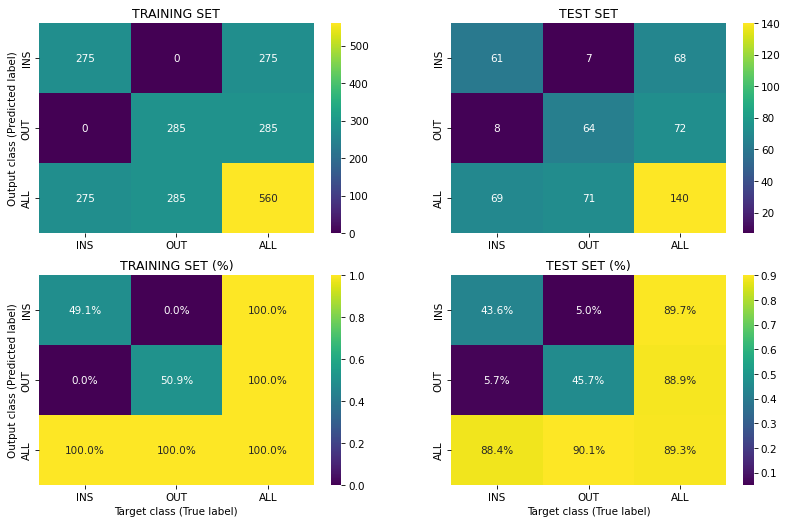

In [30]:
ucml2.plot_expanded_confusion_matrix(clf, X_train, y_train, X_test, y_test)

##### 2.5.2 Feature importance evaluation in gradient boosting using "Permutation Importance"

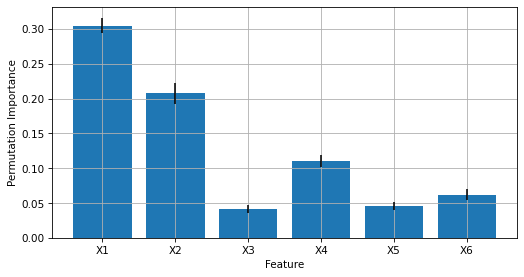

In [31]:
importances_bag_class_estim = permutation_importance(GB_class_estim, 
                                    X_train[INPUTS_DT], y_train,
                                    n_repeats=10,
                                    random_state=0)

fig = plt.figure(2, figsize=(8, 4)) 
plt.bar(INPUTS_DT, importances_bag_class_estim.importances_mean, yerr=importances_bag_class_estim.importances_std)
plt.xlabel('Feature')
plt.ylabel('Permutation Importance')
plt.grid()
plt.show()

In [32]:
## GRADIENT BOOSTING CON GRID SEARCH.
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

# Definición del pipeline con el estimador GradientBoostingClassifier
pipe = Pipeline(steps=[('GB', GradientBoostingClassifier(loss='log_loss', random_state=0))])

# Definición del grid de parámetros a explorar
param_grid = {
    'GB__n_estimators': [100, 500, 1000],
    'GB__learning_rate': [0.1, 0.5, 1.0],
    'GB__max_depth': [1, 2, 3],
    'GB__min_samples_split': [2, 5, 10],
    'GB__min_samples_leaf': [1, 2, 4],
    'GB__max_features': [0.5, 1.0, None]  # Puedes ajustar según convenga
}

# Configuración de GridSearchCV
n_folds = 10
grid_search = GridSearchCV(estimator=pipe,
                           param_grid=param_grid,
                           cv=n_folds,
                           n_jobs=-1,
                           refit=True)

# Supongamos que tienes X_train e y_train definidos previamente
grid_search.fit(X_train, y_train)

# Para ver el mejor parámetro encontrado y el score:
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor score:", grid_search.best_score_)

Mejores parámetros: {'GB__learning_rate': 0.5, 'GB__max_depth': 3, 'GB__max_features': 1.0, 'GB__min_samples_leaf': 1, 'GB__min_samples_split': 5, 'GB__n_estimators': 500}
Mejor score: 0.9214285714285715
